In [13]:
import multiprocessing

#load packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost
from sklearn.metrics import classification_report, confusion_matrix, recall_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.utils.class_weight import compute_class_weight

In [16]:
#data

df = pd.read_parquet(
    r"D:\Universität\Master\Semester2\RealWorld_ML_Problems\Data\output\bookmeas\bookmeas_e_2025-03-19_to_2025-03-28.parquet")  #adjust path

In [17]:
#train-test-split

label_col = 'target'

X = df.drop(columns=label_col)
y = df[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [18]:
#compute class weights

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

#further boost for class 2

weight_boost = {0: 1.0, 1: 1.5, 2: 3.0}
class_weights = {class_label: weight * weight_boost[class_label] for class_label, weight in zip(classes, weights)}
print("Class Weights:", class_weights)

#sample weights

sample_weights = y_train.map(class_weights)

Class Weights: {np.float64(0.0): np.float64(0.3334468718867008), np.float64(1.0): np.float64(1547.0083612040135), np.float64(2.0): np.float64(57819.4375)}


In [20]:
#GridSearch parameter
n_jobs = max(multiprocessing.cpu_count() - 1, 1)

param_grid = {
    'learning_rate': [0.03, 0.05],
    'max_depth': [5, 6],
    'n_estimators': [100, 150],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0.2, 0.4]
}

#base model

base_model = xgboost.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_jobs=n_jobs,
    random_state=42,
    verbosity=2
)

#GridSearchCV with recall optimization

recall_scorer = make_scorer(recall_score, average='macro')

grid_model = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=5,
    verbose=2,
    n_jobs=n_jobs,
)

In [6]:
#train model

grid_model.fit(X_train, y_train, sample_weight=sample_weights)

best_model = grid_model.best_estimator_
print("Best Params:", grid_model.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[23:03:16] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (925111, 222, 205172769).
Best Params: {'colsample_bytree': 0.9, 'gamma': 0.4, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 150}


In [7]:
#prediction with tuned thresholds

y_proba = best_model.predict_proba(X_test)

thresholds = {
    0: 0.6,  # no error
    1: 0.25,  # suspect
    2: 0.15  # error
}

y_pred_threshold = []
for row in y_proba:
    if row[2] > thresholds[2]:
        y_pred_threshold.append(2)
    elif row[1] > thresholds[1]:
        y_pred_threshold.append(1)
    else:
        y_pred_threshold.append(0)


Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      1.00    231199
         1.0       0.07      0.93      0.13        75
         2.0       0.00      0.25      0.00         4

    accuracy                           0.99    231278
   macro avg       0.36      0.73      0.38    231278
weighted avg       1.00      0.99      1.00    231278

Confusion Matrix:
 [[229711    946    542]
 [     0     70      5]
 [     0      3      1]]


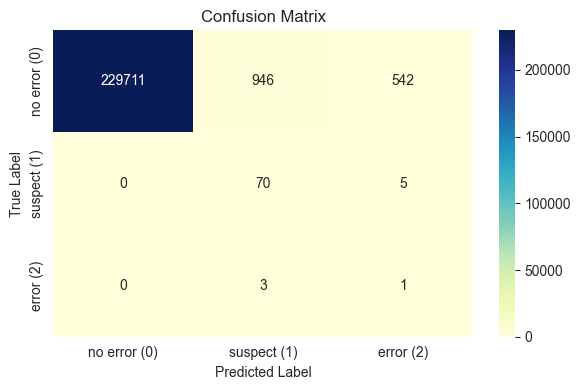

In [8]:
#evaluation

print("\nClassification Report:\n", classification_report(y_test, y_pred_threshold))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_threshold))

cm = confusion_matrix(y_test, y_pred_threshold)
labels = ['no error (0)', 'suspect (1)', 'error (2)']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

XAI

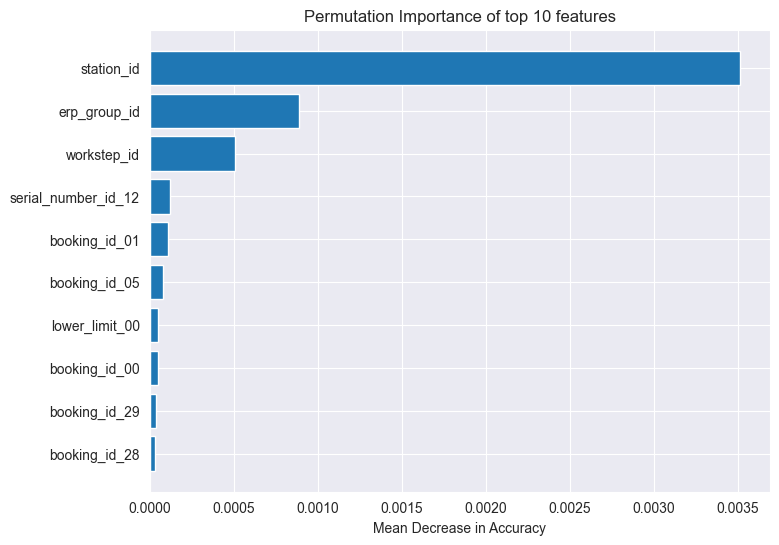

In [9]:
#permutation importance

from sklearn.inspection import permutation_importance

#calculation

perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=0)

#plot

sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(8, 6))
plt.barh(X_test.columns[sorted_idx][-10:], perm_importance.importances_mean[sorted_idx][-10:])
plt.xlabel("Mean Decrease in Accuracy")
plt.title("Permutation Importance of top 10 features")
plt.show()

D:\Universität\Master\Semester2\RealWorld_ML_Problems\Code\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


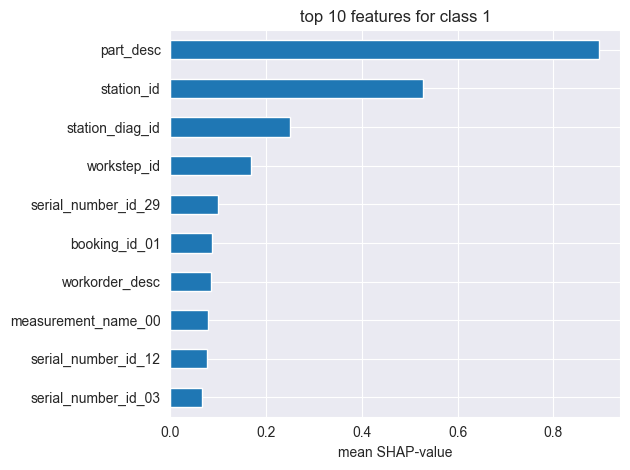

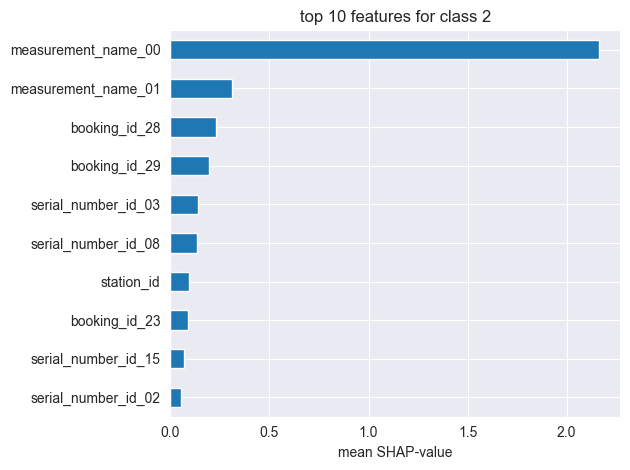

In [11]:
#shap
import shap

# SHAP-explainer for best model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

#only classes 1 and 2 (error anaylsis)

classes_to_plot = [1, 2]

for cls in classes_to_plot:
    shap_values_class = shap_values[:, :, cls]

    #mean absolute importance for each feature

    importances_class = np.abs(shap_values_class).mean(axis=0)

    #top 10 features

    pd.Series(importances_class, index=X_test.columns) \
        .nlargest(10) \
        .plot(kind='barh')

    plt.title(f"top 10 features for class {cls}")
    plt.xlabel("mean SHAP-value")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


 global overview for all classes


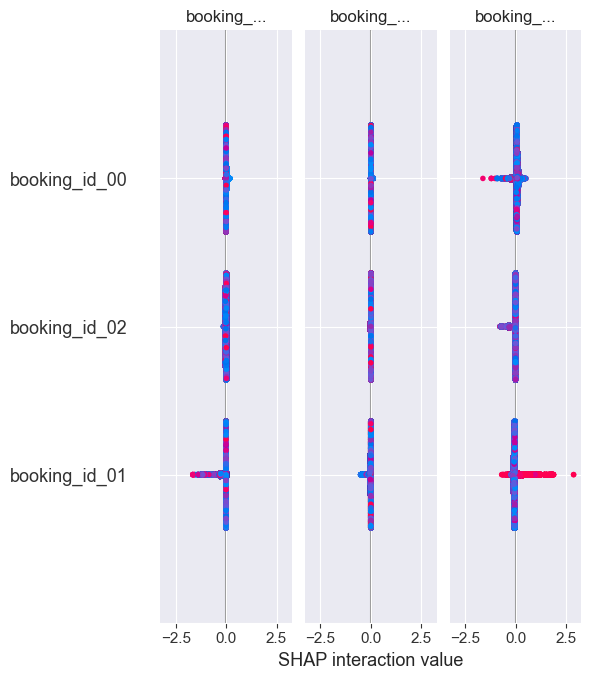

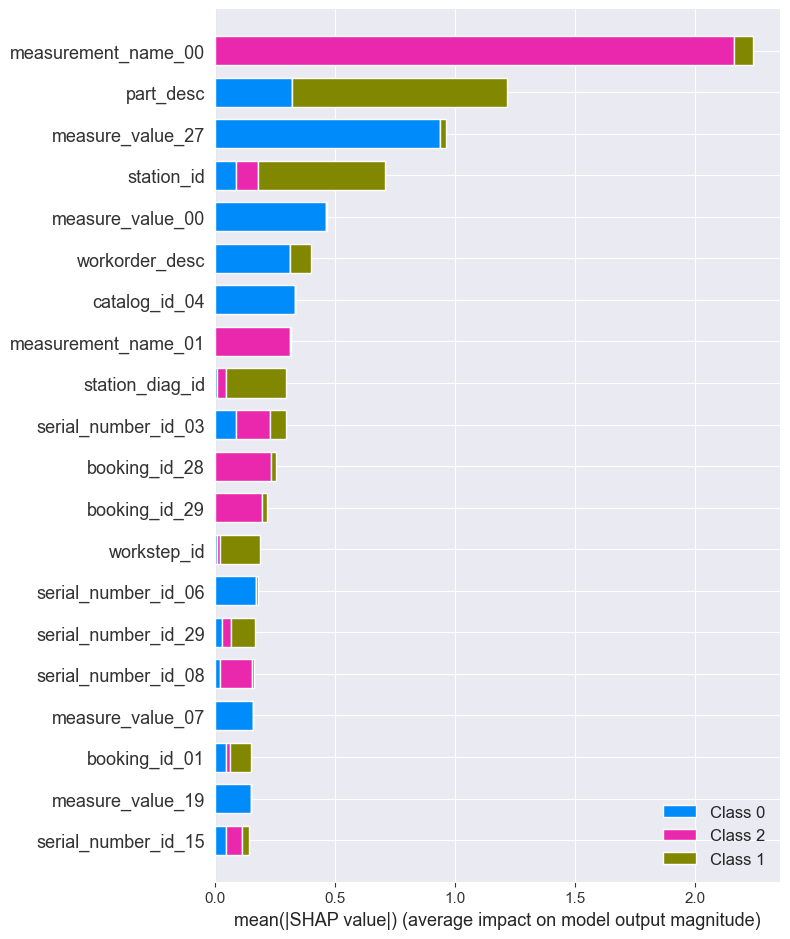


--- SHAP summary for class no error (0) 


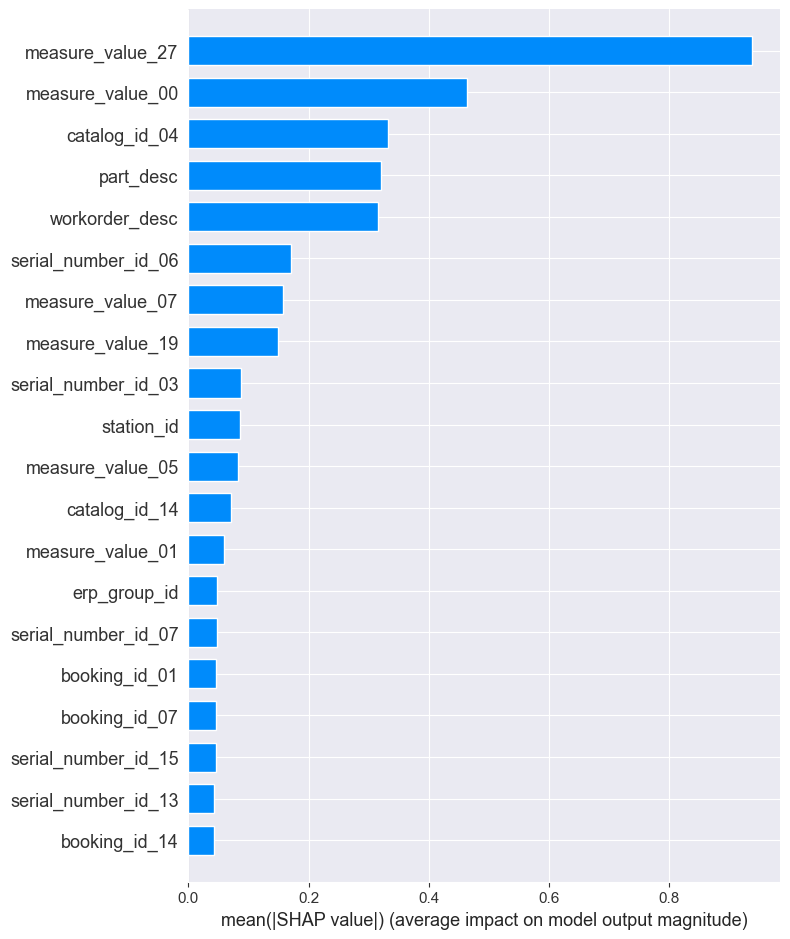

top feature for no error (0): measure_value_27


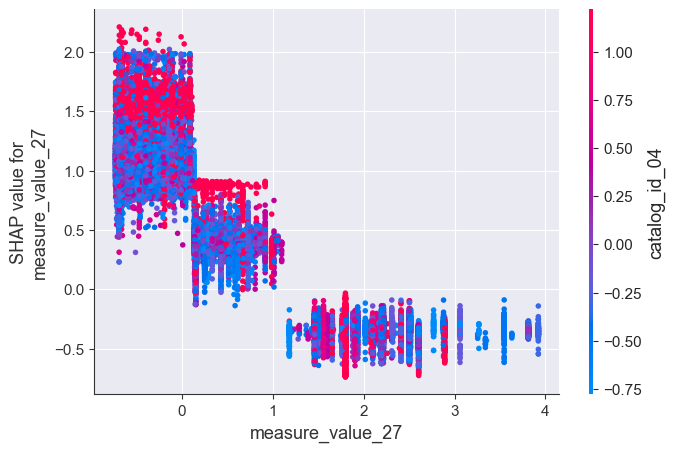


--- SHAP summary for class suspect (1) 


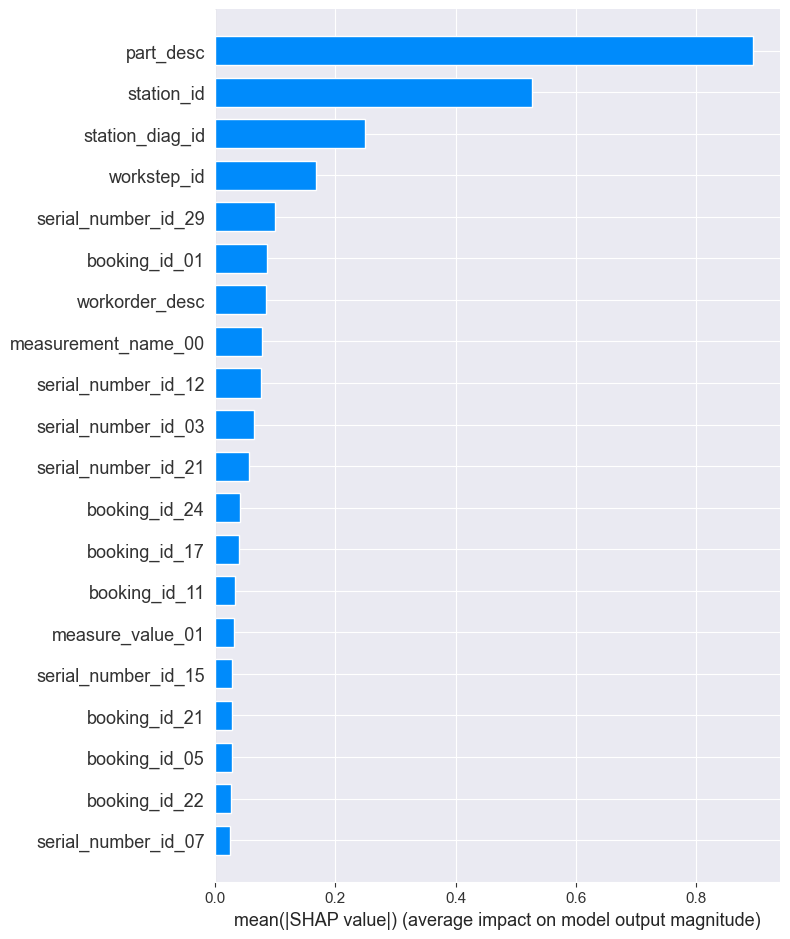

top feature for suspect (1): part_desc


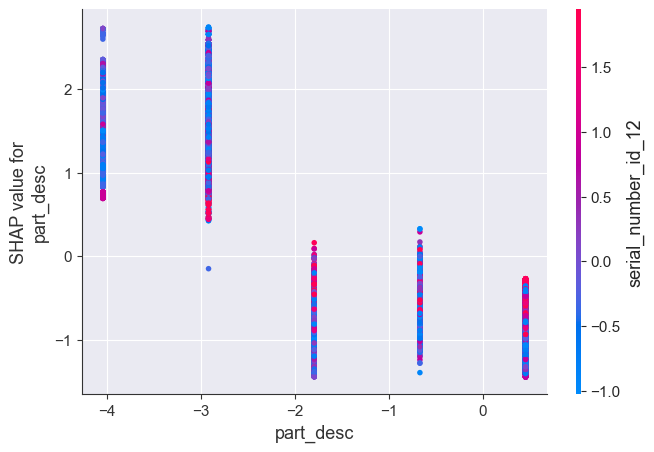


--- SHAP summary for class error (2) 


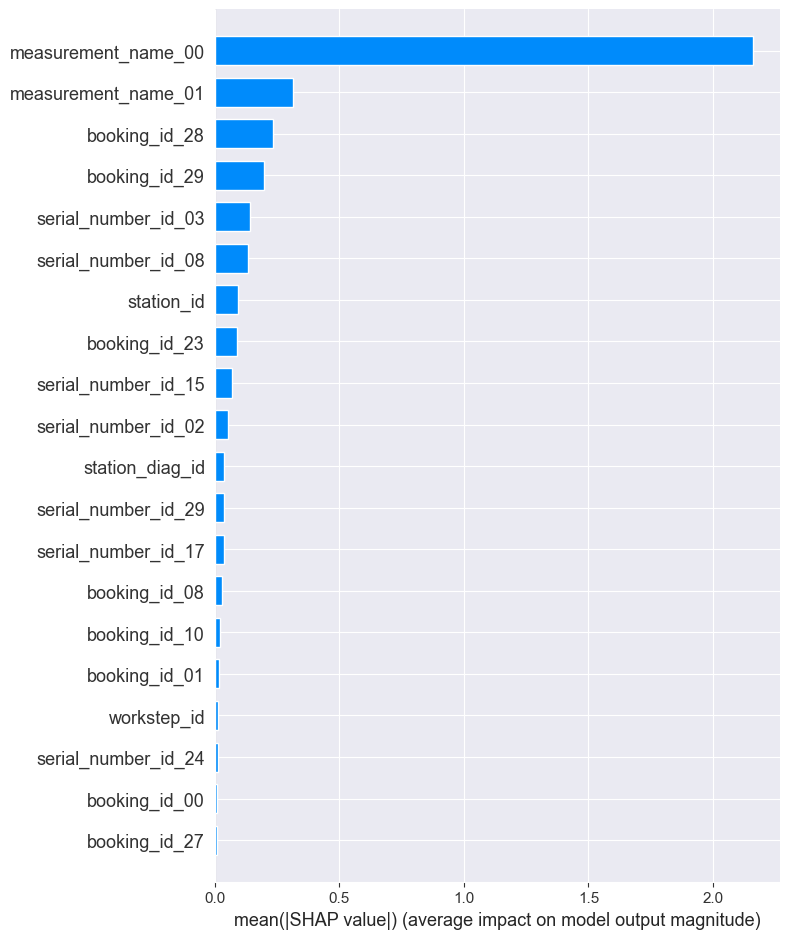

top feature for error (2): measurement_name_00


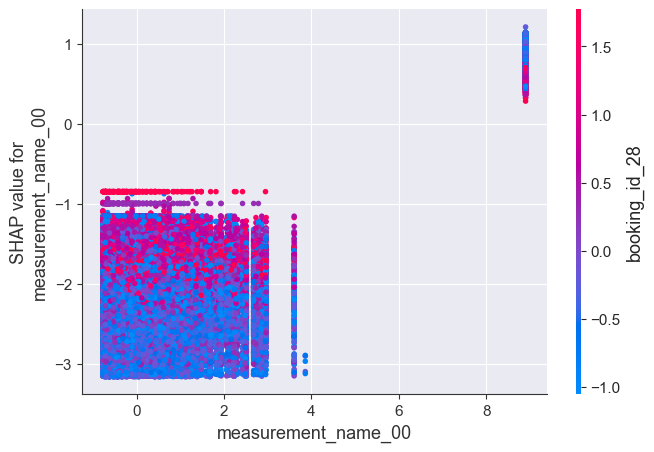

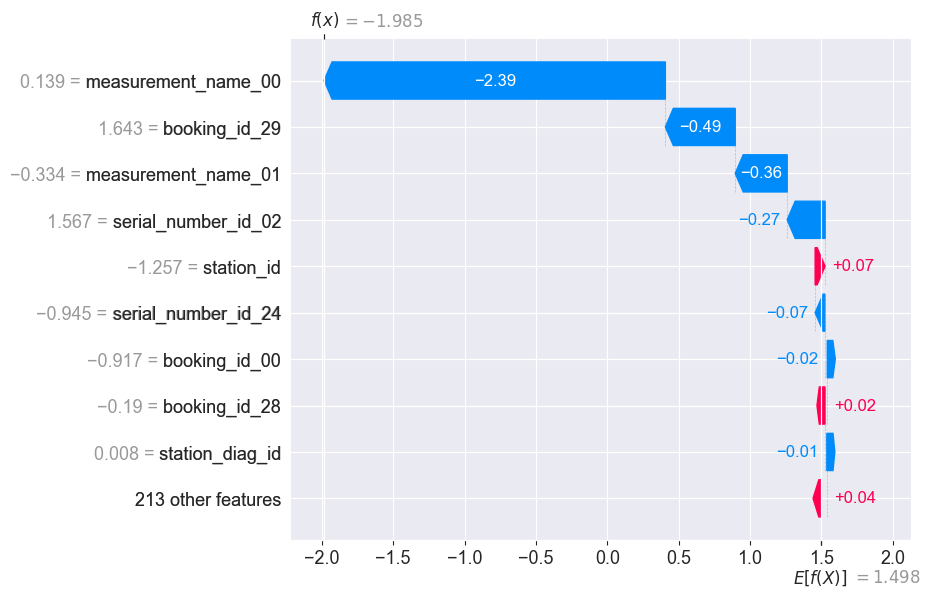


 interaction plot for error (class 2)


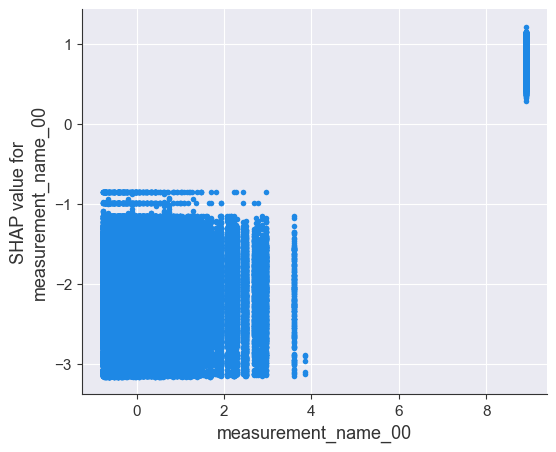

In [12]:
#create SHAP-explainer

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

#global overview for all classes 

print("\n global overview for all classes")

shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

#class-specific view

class_labels = ['no error (0)', 'suspect (1)', 'error (2)']

for class_idx, class_name in enumerate(class_labels):
    print(f"\n--- SHAP summary for class {class_name} ")
    shap.summary_plot(shap_values[:, :, class_idx], X_test, plot_type="bar")

    #top features (dependencies)

    top_feature_idx = np.argsort(np.abs(shap_values[:, :, class_idx]).mean(0))[-1]
    top_feature = X_test.columns[top_feature_idx]
    print(f"top feature for {class_name}: {top_feature}")

    shap.dependence_plot(top_feature, shap_values[:, :, class_idx], X_test)

#local explainations

sample_index = 0  #index of an example (first observation for class error)
shap.initjs()
shap.force_plot(
    explainer.expected_value[2],
    shap_values[sample_index, :, 2],
    X_test.iloc[sample_index],
    feature_names=X_test.columns
)

#waterfall plot

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index, :, 2],
        base_values=explainer.expected_value[2],
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

#interaction plot for error class

print("\n interaction plot for error (class 2)")
shap.dependence_plot(
    top_feature,
    shap_values[:, :, 2],
    X_test,
    interaction_index=None
)